# Inteligencia de Negocios

1. Importación de las referencias a usar

In [51]:
# TODO: import
# Importar Pandas y NumPy
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt  # Para visualización de datos

# Configuración para visualizaciones en línea en Colab
%matplotlib inline

2. Cargar el archivo CSV de los datos de COVID 19 México

In [52]:
# TODO: Cargar en un Pandas DataFrame los datos
# Leer un archivo CSV
data = pd.read_csv('/content/COVID19MEXICO.csv')

3. Encontrar cuántos muertos hubo para los estados de: Tamaulipas, Nuevo León, San Luis Potosí y Veracruz

In [46]:
# TODO Encontrar la cantidad de muertos por COVID para los estados e imprimirlos.
# Estados de interés por número de entidad
estados_interes = [28, 19, 24, 30]

# Filtrar los datos para incluir solo los estados de interés
muertos_por_estado_interes = data[data['ENTIDAD_RES'].isin(estados_interes)]

# Contar la cantidad de muertos por estado
muertos_por_estado_interes = muertos_por_estado_interes[muertos_por_estado_interes['FECHA_DEF'] != '9999-99-99'].groupby('ENTIDAD_RES')['FECHA_DEF'].count().reset_index(name='Muertos')

# Mostrar los resultados
print(muertos_por_estado_interes)


   ENTIDAD_RES  Muertos
0           19      504
1           24      326
2           28      190
3           30      464


4. Graficar la cantidad de intubados para cada estado: eje X estados, eje Y cantidad

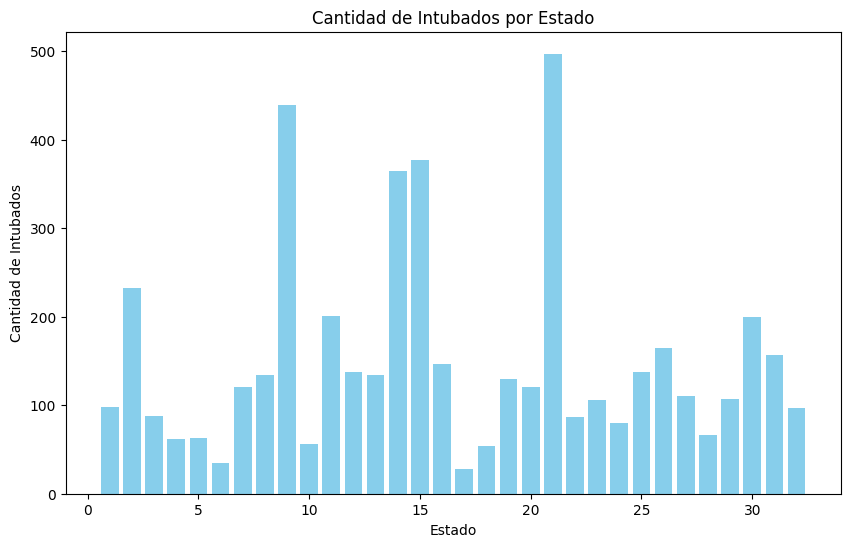

In [47]:
# TODO Graficar

# Filtrar los datos para incluir solo casos intubados
intubados_por_estado = data[data['INTUBADO'] == 1]

# Contar la cantidad de intubados por estado
intubados_por_estado = intubados_por_estado.groupby('ENTIDAD_RES')['INTUBADO'].count().reset_index(name='Cantidad')

# Mostrar la gráfica
plt.figure(figsize=(10, 6))
plt.bar(intubados_por_estado['ENTIDAD_RES'], intubados_por_estado['Cantidad'], color='skyblue')
plt.xlabel('Estado')
plt.ylabel('Cantidad de Intubados')
plt.title('Cantidad de Intubados por Estado')
plt.show()


5. Encontrar el porcentaje de intubatos de que murieron

In [48]:
# TODO: Encontrar los intubados totales a imprimir el porcentaje de los que murieron
# Contar los casos intubados
total_intubados = data['INTUBADO'].eq(1).sum()

# Filtrar los casos intubados y contar los fallecidos
intubados_fallecidos = data[data['INTUBADO'] == 1]['FECHA_DEF'] != '9999-99-99'
intubados_fallecidos = intubados_fallecidos.sum()

# Calcular el porcentaje de fallecidos entre los intubados
porcentaje_fallecidos = (intubados_fallecidos / total_intubados) * 100

# Imprimir los resultados
print(f'Total de intubados: {total_intubados}')
print(f'Fallecidos entre intubados: {intubados_fallecidos}')
print(f'Porcentaje de fallecidos entre intubados: {porcentaje_fallecidos:.2f}%')

Total de intubados: 4830
Fallecidos entre intubados: 1696
Porcentaje de fallecidos entre intubados: 35.11%


6. Graficar los datos correspondientes a los muertos en relación a los meses pasados. Eje X Meses (año-mes), eje Y Cantidad de muertos.

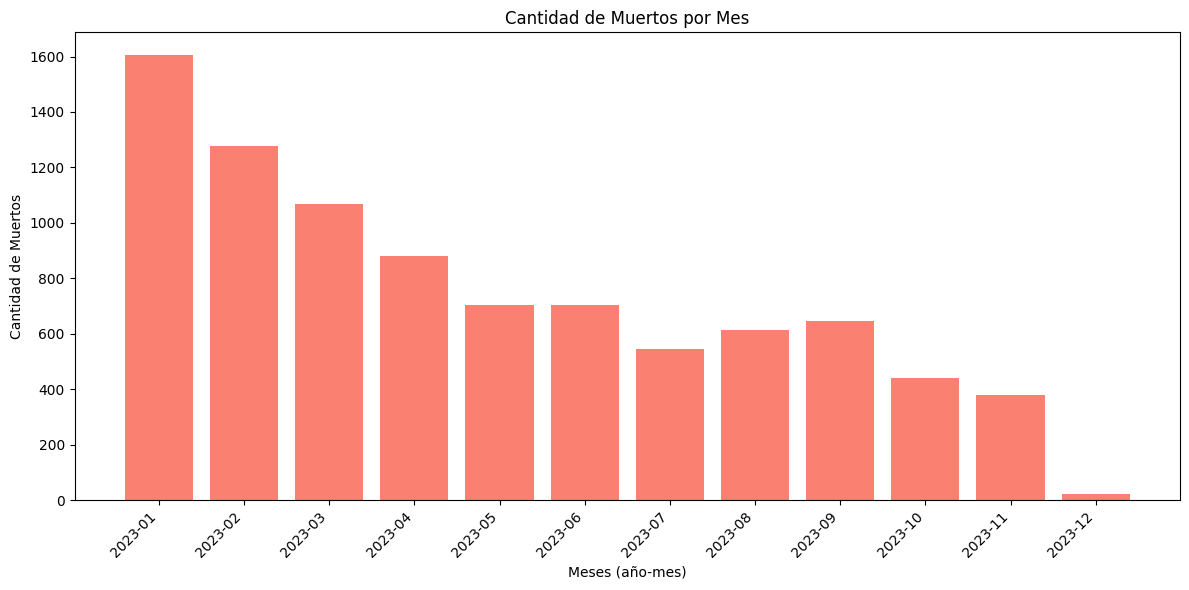

In [50]:
# TODO: Graficar
# Convertir la columna FECHA_DEF a formato de fecha
data['FECHA_DEF'] = pd.to_datetime(data['FECHA_DEF'], errors='coerce')

# Crear una nueva columna con el mes y año
data['Mes_Año'] = data['FECHA_DEF'].dt.to_period('M')

# Filtrar los datos para excluir fechas nulas (9999-99-99)
muertos_por_mes = data[data['FECHA_DEF'].notnull()]

# Contar la cantidad de muertos por mes
muertos_por_mes = muertos_por_mes.groupby('Mes_Año')['FECHA_DEF'].count().reset_index(name='Cantidad_Muertos')

# Mostrar la gráfica
plt.figure(figsize=(12, 6))
plt.bar(muertos_por_mes['Mes_Año'].astype(str), muertos_por_mes['Cantidad_Muertos'], color='salmon')
plt.xlabel('Meses (año-mes)')
plt.ylabel('Cantidad de Muertos')
plt.title('Cantidad de Muertos por Mes')
plt.xticks(rotation=45, ha='right')  # Rotar las etiquetas del eje X para mejor legibilidad
plt.tight_layout()
plt.show()